In [2]:
require(data.table)
require(tidyverse)
require(phyloseq)
require(ggplot2)
require(RColorBrewer)
require(metacoder)
require(vegan)
require(DESeq2)

In [3]:
ps<-readRDS(file = "/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/BEL_16S_ITS2/BEL_ITS2_outputs/ps_all_ITS2.rds")
#removing any taxa that don't show up in any samples to speed up the process
ps
ps_prune <- prune_taxa(taxa_sums(ps) > 0, ps)
ps_prune

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 257 taxa and 479 samples ]
sample_data() Sample Data:       [ 479 samples by 26 sample variables ]
tax_table()   Taxonomy Table:    [ 257 taxa by 8 taxonomic ranks ]

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 256 taxa and 479 samples ]
sample_data() Sample Data:       [ 479 samples by 26 sample variables ]
tax_table()   Taxonomy Table:    [ 256 taxa by 8 taxonomic ranks ]

### try not normalizing to ensure negatives have low abundances
- when normalize all abundances are 1E07, i do not like that 

# prep for ITS2 profile plots

In [37]:
# convert the sample_data() within a phyloseq object to a vegan compatible data object
pssd2veg <- function(ps_prune) {
  sd <- sample_data(ps_prune)
  return(as(sd,"data.frame"))
}
#using phyloseq nmds plot no chloroplast
sample <- pssd2veg(ps_prune)

In [38]:
sample <- as.data.frame(sample_data(ps_prune))
#save sammple names as a column so tidy doesn't get rid of it during filtering
sample$SampleID <- rownames(sample)

## dates in chron order

In [39]:
# 2. reorder MonthYear as a factor in chronological order
sample$Month_year <- factor(sample$Month_year,levels = c("Jun 2019","May 2022","Oct 2022", "Dec 2022", "Sep 2023","Nov 2023","Dec 2023","Jan 2024","Feb 2024","Apr 2024","Jun 2024","Aug 2024"))

In [40]:
# Restore rownames
rownames(sample) <- sample$SampleID
#check
head(rownames(sample))
NROW(sample_names(ps_prune))

[1] "012024_BEL_CBC_T1_557_SSID" "012024_BEL_CBC_T1_559_MCAV"
[3] "012024_BEL_CBC_T1_561_OANN" "012024_BEL_CBC_T1_563_PSTR"
[5] "012024_BEL_CBC_T1_565_PAST" "012024_BEL_CBC_T2_585_OFAV"

[1] 479

In [41]:
#take the filtered metadata I just worked on — with cleaned rows, and correct sample names — and replace the old sample data in ps_clean with this cleaned version
sd_clean <- phyloseq::sample_data(sample)
sample_data(ps_prune) <- sd_clean
head(sample_data(ps_prune))

,V1,Date_Extracted,Raw_ng_ul,Date_Enriched,Microbe_Location,Month_year,colony,CollectionDate,Species,Health_status,⋯,Transect,sample_uid,data_set_uid,host_family,host_genus,host_species,collection_date,collection_depth,DateFormatted,SampleID
,<int>,<chr>,<chr>,<chr>,<chr>,<fct>,<chr>,<fct>,<chr>,<chr>,⋯,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<int>,<int>,<date>,<chr>
012024_BEL_CBC_T1_557_SSID,1,2_17_2025,44.6,,,Jan 2024,1_3,1/10/24,SSID,Healthy,⋯,CBC30N,272206,1503,Rhizangiidae,Siderastrea,sidera,20240110,8,2024-01-10,012024_BEL_CBC_T1_557_SSID
012024_BEL_CBC_T1_559_MCAV,2,2_17_2025,14.8,,,Jan 2024,1_24,1/10/24,MCAV,Healthy,⋯,CBC30N,272302,1503,Montastraeidae,Montastrea,cavernosa,20240110,8,2024-01-10,012024_BEL_CBC_T1_559_MCAV
012024_BEL_CBC_T1_561_OANN,3,2_17_2025,18,,,Jan 2024,1_25,1/10/24,OANN,Healthy,⋯,CBC30N,272398,1503,Merulinidae,Orbicella,annularis,20240110,8,2024-01-10,012024_BEL_CBC_T1_561_OANN
012024_BEL_CBC_T1_563_PSTR,4,2_17_2025,35.8,,,Jan 2024,1_12,1/10/24,PSTR,Healthy,⋯,CBC30N,272207,1503,Faviidae,Pseudodiploria,strigosa,20240110,8,2024-01-10,012024_BEL_CBC_T1_563_PSTR
012024_BEL_CBC_T1_565_PAST,5,2_17_2025,7.72,,,Jan 2024,1_21,1/10/24,PAST,Bleached_Tissue,⋯,CBC30N,272494,1503,Poritidae,Porites,asteroides,20240110,8,2024-01-10,012024_BEL_CBC_T1_565_PAST
012024_BEL_CBC_T2_585_OFAV,6,2_17_2025,71.6,,,Jan 2024,2_76,1/12/24,OFAV,Healthy,⋯,SR30N,272495,1503,Merulinidae,Orbicella,faveolata,20240112,8,2024-01-12,012024_BEL_CBC_T2_585_OFAV


# taxa

## clade

In [42]:
clade_counts <- table(tax_table(ps_prune)[, "Clade"])

keep <- names(clade_counts[clade_counts > 1])

ps_filtered <- subset_taxa(ps_prune, Clade %in% keep)

# confirm that singleton is removed
table(tax_table(ps_filtered)[, "Clade"])


 A  B  C  D  G 
80 96 55 21  4 

In [43]:
    # how many unique family taxa are there?
length(unique(tax_table(ps_filtered)[, "Clade"]))

rank_names(ps_filtered)

#check if clade is a factor
class(tax_table(ps_filtered)[, "Clade"])

[1] 5

[1] "Clade"                                            
[2] "Majority.ITS2.sequence"                           
[3] "Associated.species"                               
[4] "ITS2.profile.abundance.local"                     
[5] "ITS2.profile.abundance.DB"                        
[6] "ITS2.type.profile"                                
[7] "Sequence.accession...SymPortal.UID"               
[8] "Average.defining.sequence.proportions.and..stdev."

[1] "taxonomyTable"
attr(,"package")
[1] "phyloseq"

In [44]:
# use merge taxa instead of tax_glom bc things in the same clade may not necessarily be heirarchal
ps_clade <- merge_taxa(ps_filtered, "Clade")

### assiging colors 

In [45]:
options(repr.plot.width=20, repr.plot.height=15)

In [46]:
clade <- unique(tax_table(ps_clade)[, "Clade"])

base_palette <- colorRampPalette(brewer.pal(9, "Set1"))(9)

cladecolors <- sample(base_palette, length(clade))
cladecolors <- setNames(cladecolors, clade)

### by sample facetted by species 
- AWESOME! negative controls actually don't have a high abundacne
- using scales=free in facet bc otherwise one SSID with many reads gets in the way of reading

<Guides[1] ggproto object>

colour : <GuideLegend>

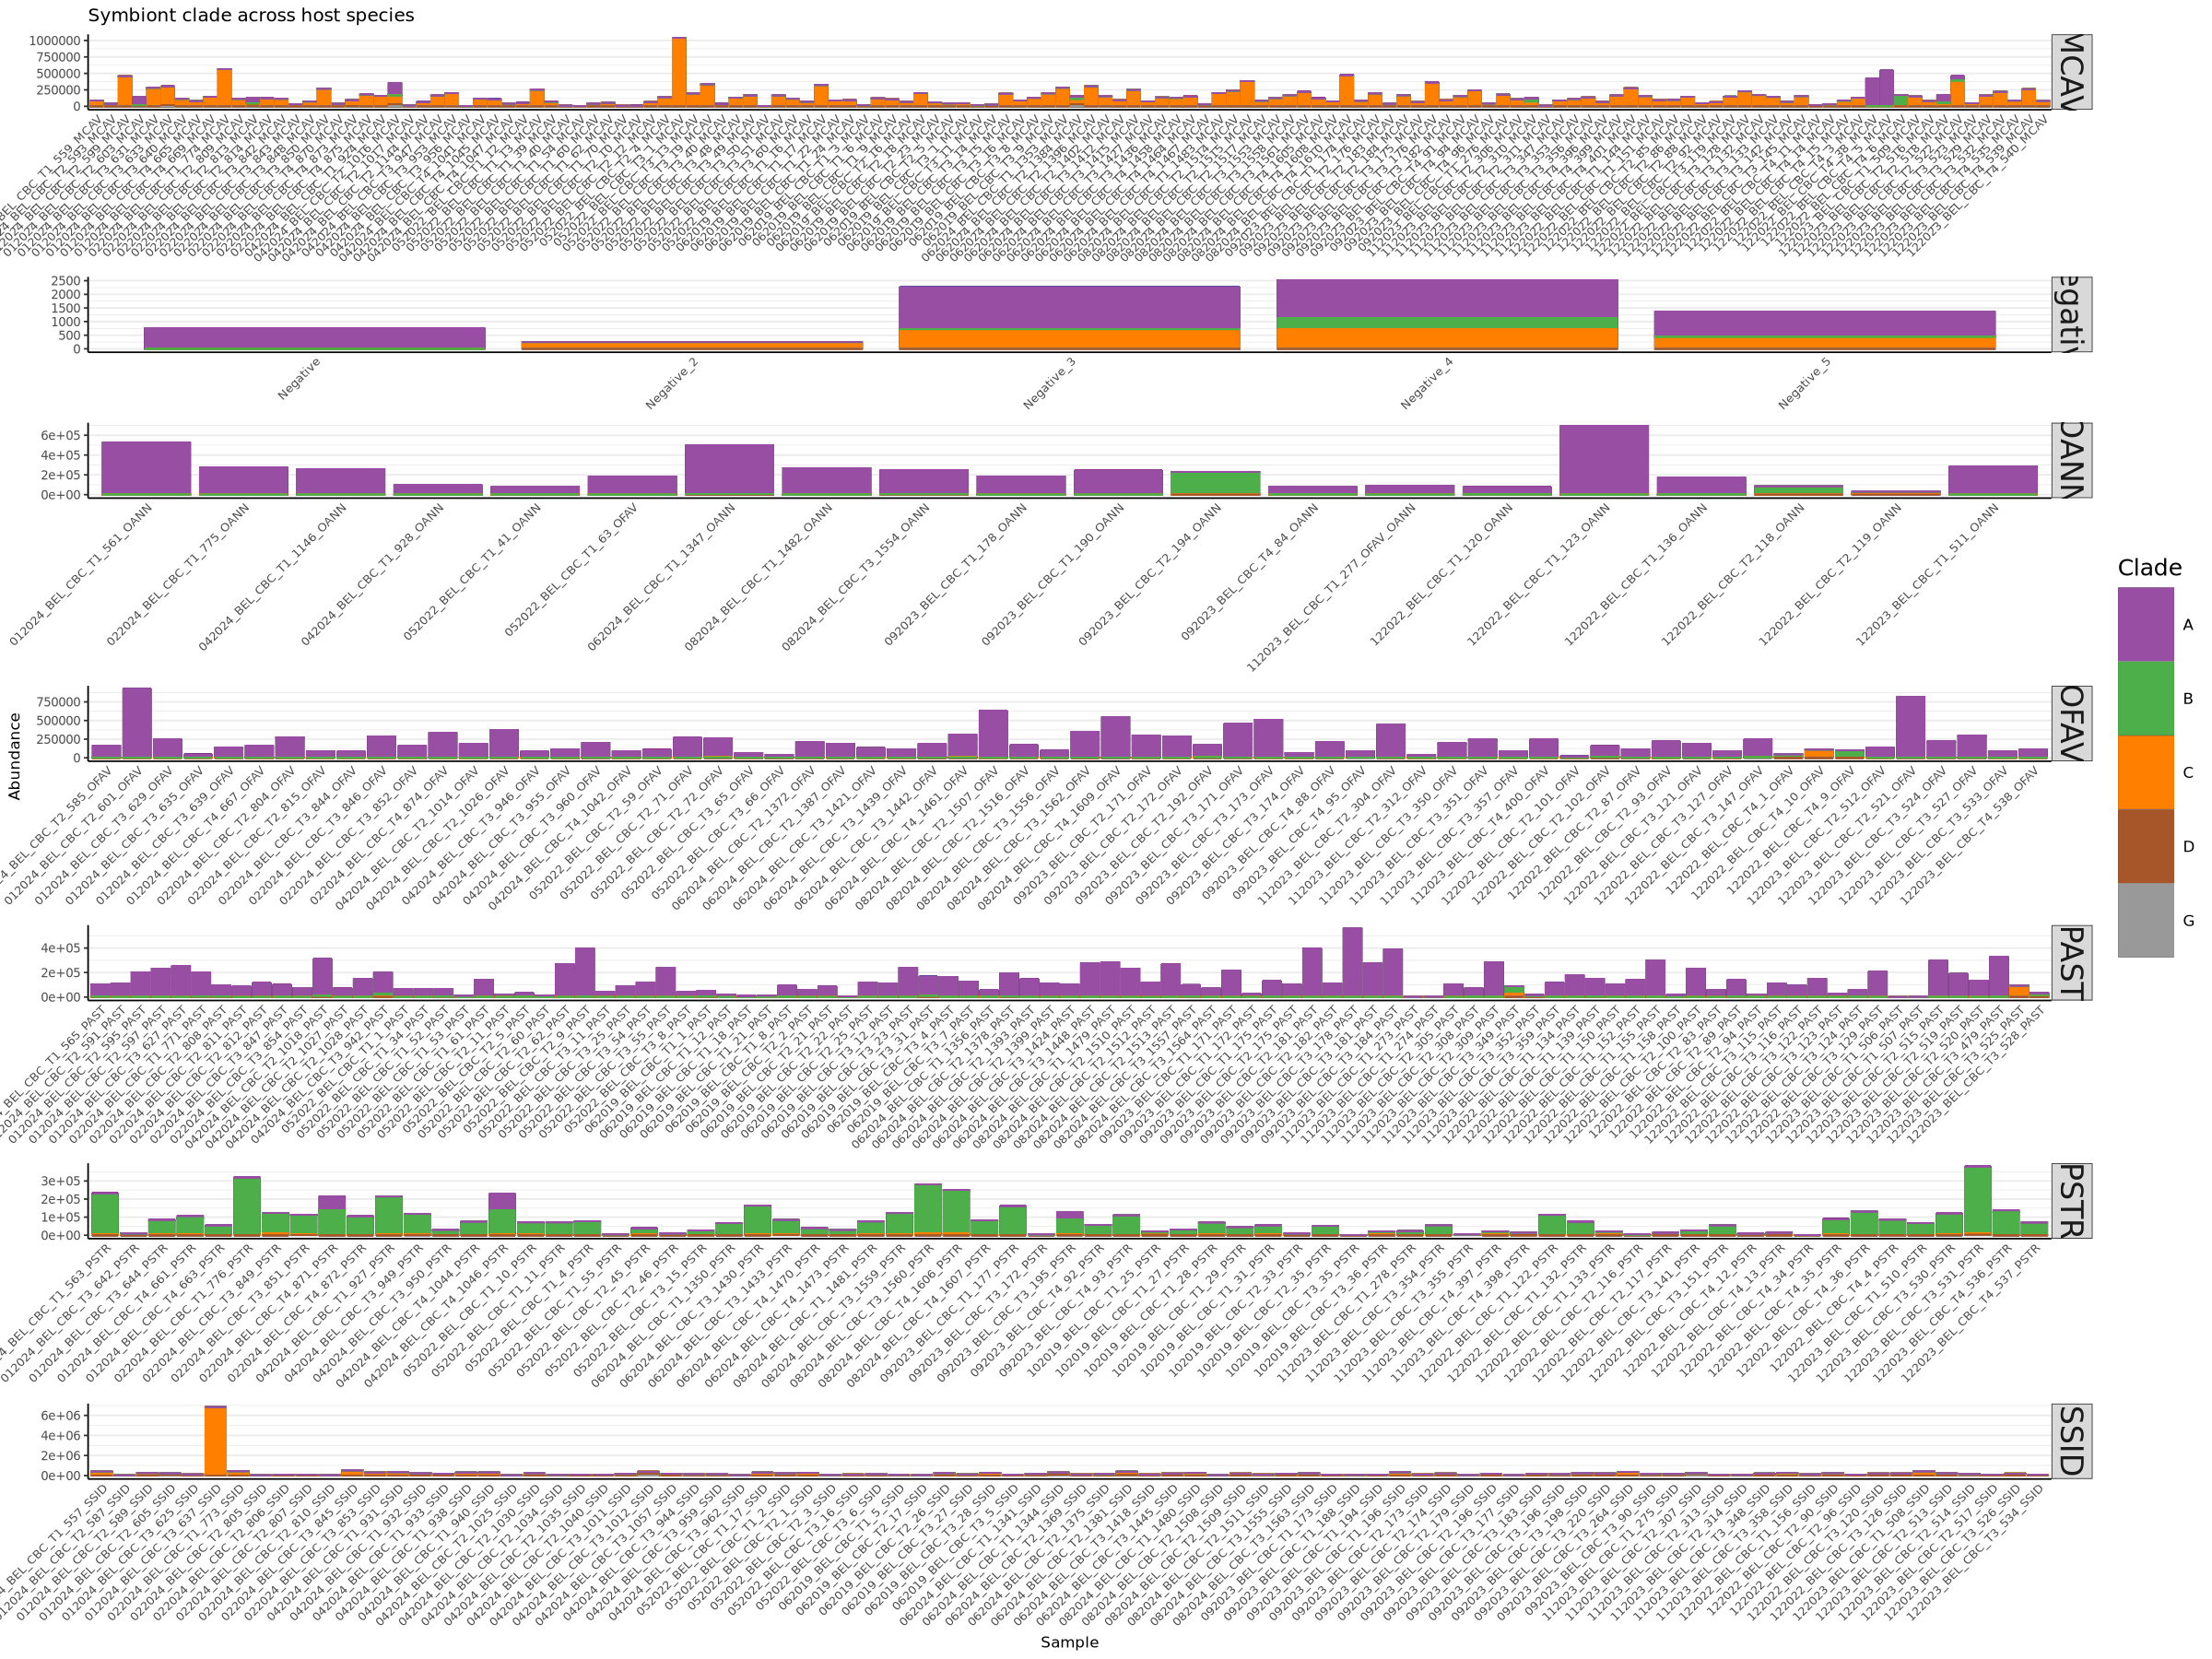

In [49]:
clade <- plot_bar(ps_clade, fill = "Clade") +
facet_wrap(Species ~., strip.position = "right",  ncol = 1, scales = "free") + # Set desired font size
  geom_bar(aes(color = Clade, fill = Clade), 
           stat = "identity", position = "stack") +
  labs(title = "Symbiont clade across host species",
       x = "Sample",
       y = "Abundance",
       color = "Clade") +
  scale_fill_manual(values = cladecolors, drop = TRUE) +
  scale_color_manual(values = cladecolors, drop = TRUE) +
  theme_bw() +
  theme(strip.text = element_text(size = 20), #facet text size
    legend.position = "right",
    legend.title = element_text(size = 15),
  legend.text = element_text(size = 10),
legend.key.width = unit(1.3, "cm"),     # make the legend keys wider
  legend.key.height = unit(1.7, "cm"),   # make them taller
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
    text = element_text(size =10)
  )
guides(color = guide_legend(override.aes = list(size = 6))) 
clade

### by colony facetted by species 

<Guides[1] ggproto object>

colour : <GuideLegend>

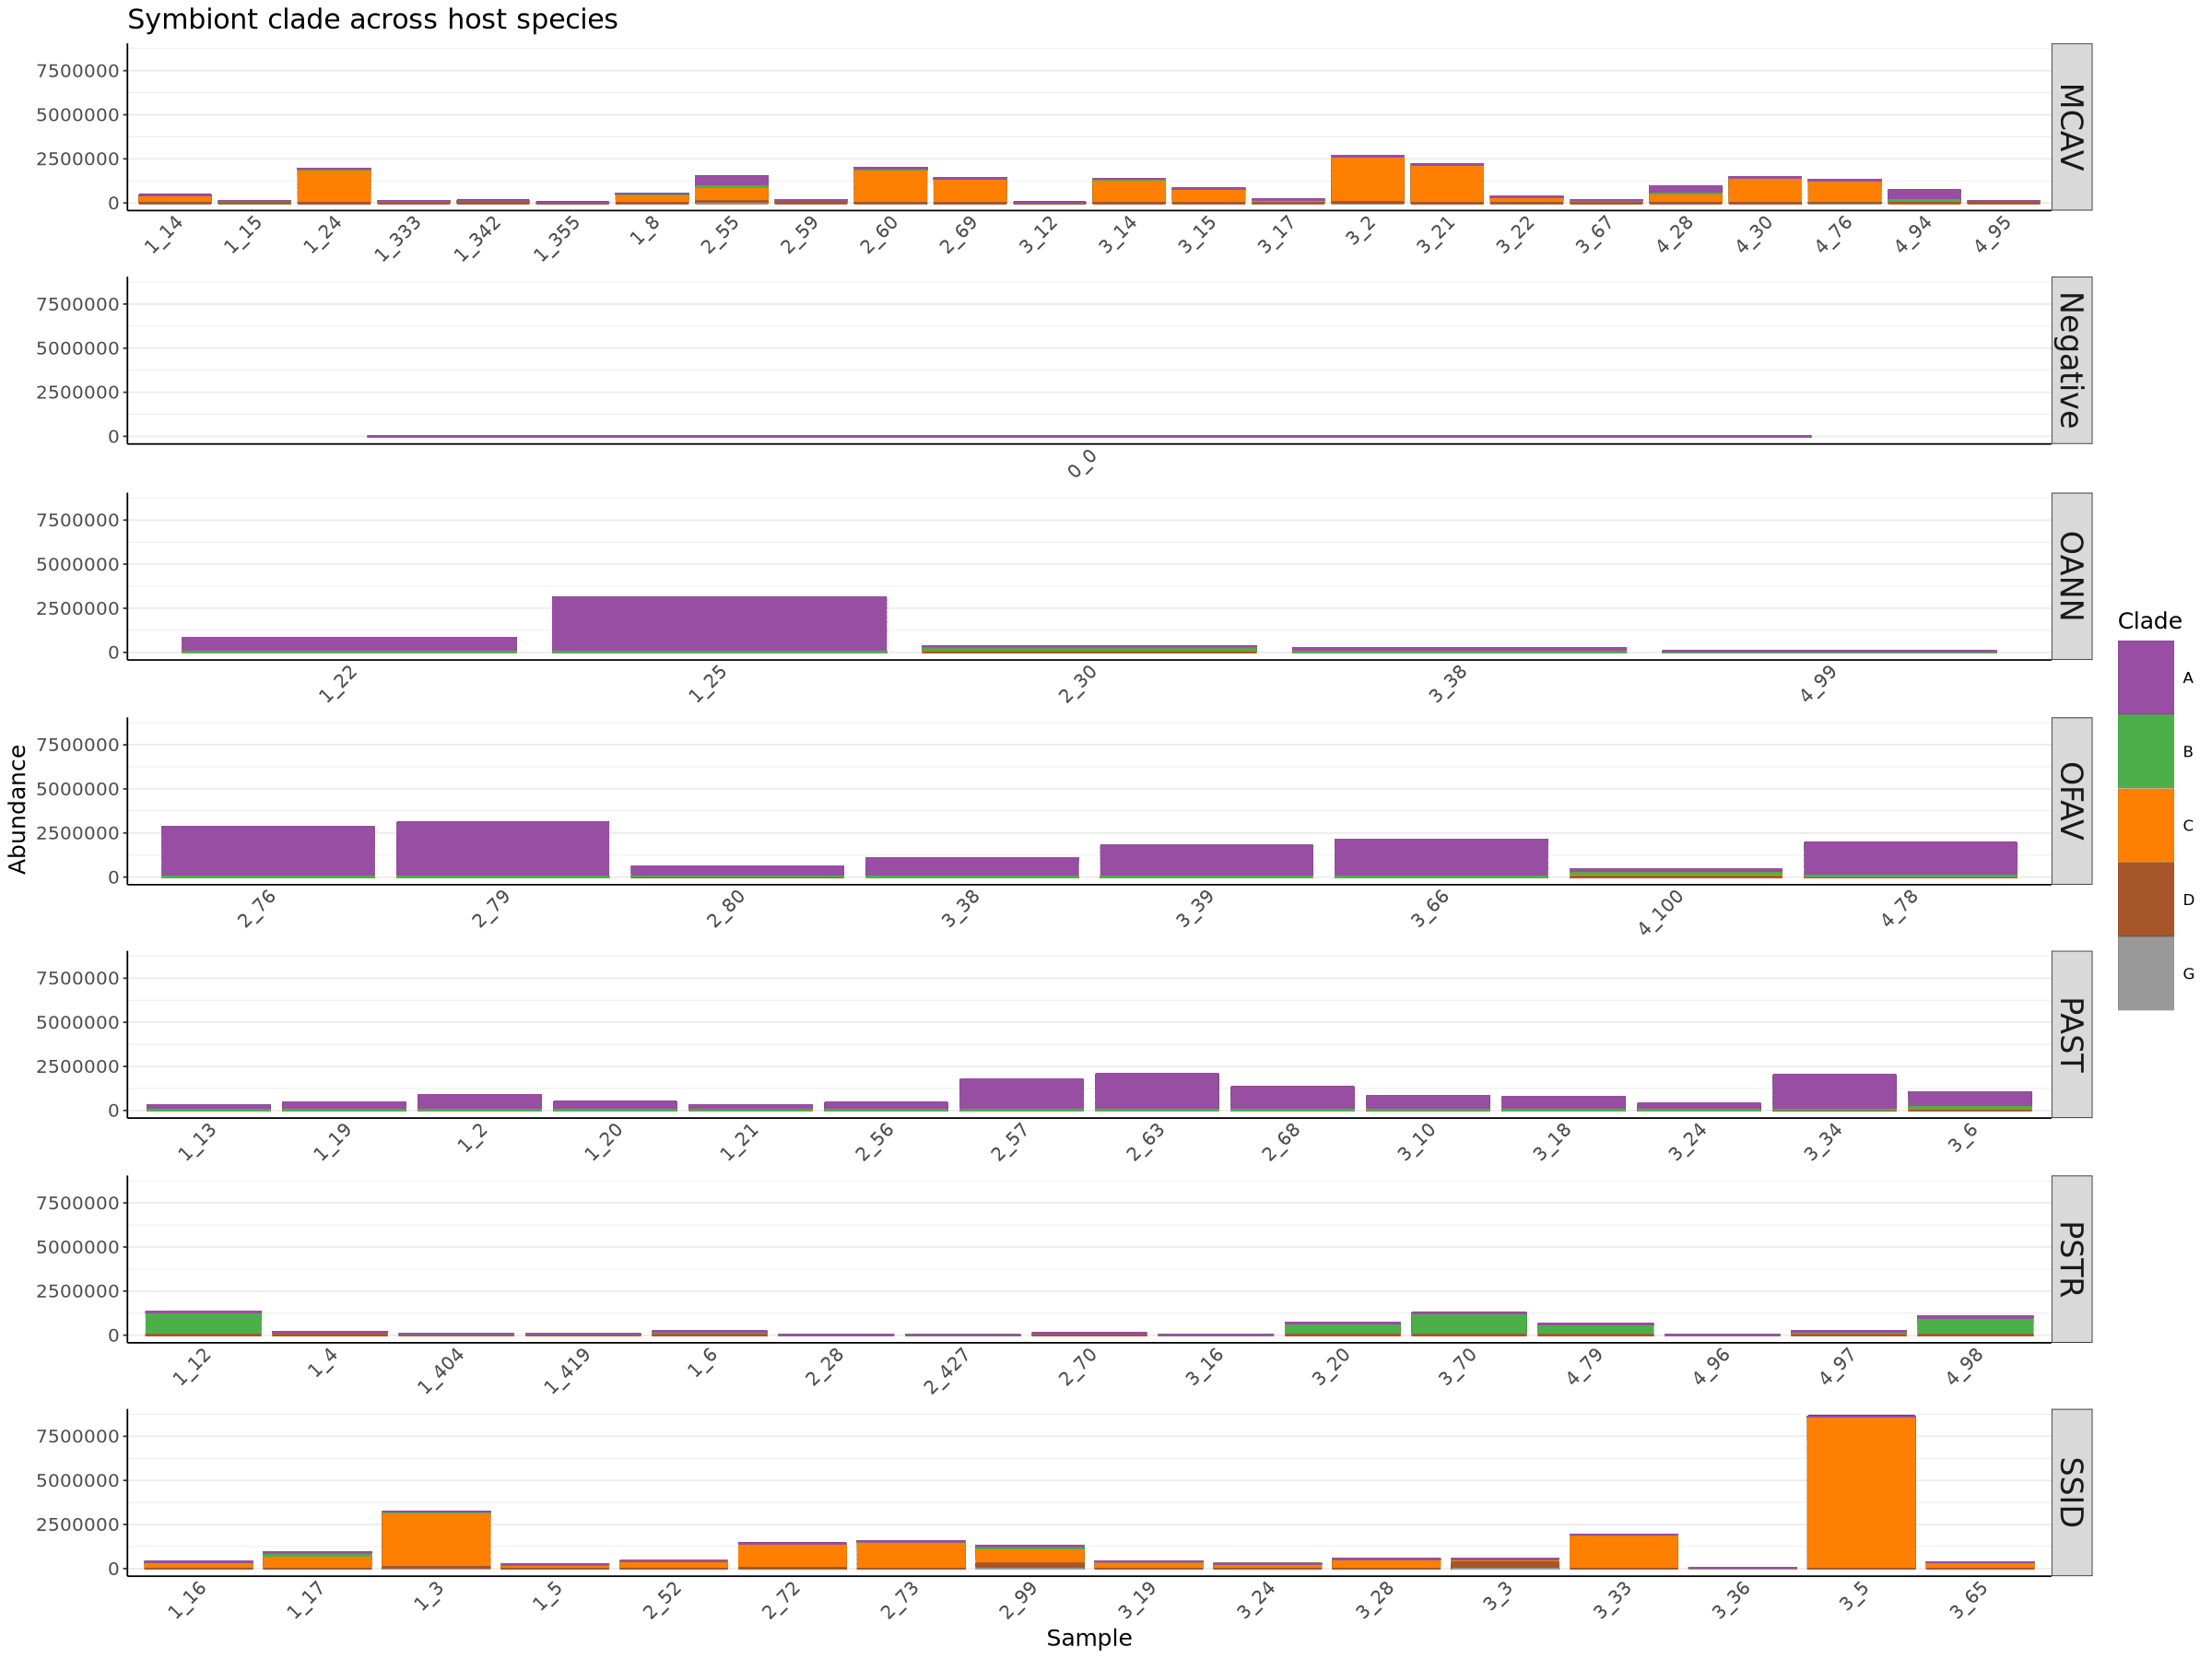

In [50]:
col_clade <- plot_bar(ps_clade,x= "colony", fill = "Clade") +
facet_wrap(Species ~., strip.position = "right",  ncol = 1, scales = "free_x") + # Set desired font size
  geom_bar(aes(color = Clade, fill = Clade), 
           stat = "identity", position = "stack") +
  labs(title = "Symbiont clade across host species",
       x = "Sample",
       y = "Abundance",
       color = "Clade") +
  scale_fill_manual(values = cladecolors, drop = TRUE) +
  scale_color_manual(values = cladecolors, drop = TRUE) +
  theme_bw() +
  theme(strip.text = element_text(size = 20), #facet text size
    legend.position = "right",
    legend.title = element_text(size = 15),
  legend.text = element_text(size = 10),
legend.key.width = unit(1.3, "cm"),     # make the legend keys wider
  legend.key.height = unit(1.7, "cm"),   # make them taller
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
    text = element_text(size = 15)
  )
guides(color = guide_legend(override.aes = list(size = 6))) 
col_clade

### its2 profile prep
-  make the its2 profiles a range of colors based on each clade

In [51]:
    # how many unique family taxa are there?
length(unique(tax_table(ps_norm)[, "ITS2.type.profile"]))

[1] 257

In [52]:
 # how many unique family taxa are there?
length(unique(tax_table(ps_norm)[, "Majority.ITS2.sequence"]))

[1] 59

In [53]:
# Extract ITS2 profiles and clades directly from phyloseq object
its2 <- psmelt(ps_norm)

profiles <- unique(as.character(its2$Majority.ITS2.sequence))
profiles <- trimws(profiles)
profiles <- profiles[!is.na(profiles)]

# Extract clade letter from each profile (e.g., "A3" -> "A")
clade <- substr(profiles, 1, 1)


In [54]:
## colors 

In [55]:
#shift base color toward white
lighten_color <- function(col, factor = 0.7) {
  rgb_col <- col2rgb(col) / 255
  lighter <- rgb_col + (1 - rgb_col) * factor
  rgb(lighter[1], lighter[2], lighter[3])
}

In [56]:
#shift base color towards black
darken_color <- function(col, factor = 0.7) {
  rgb_col <- col2rgb(col) / 255
  darker <- rgb_col * (1 - factor)
  rgb(darker[1], darker[2], darker[3])
}

In [57]:
profile_colors <- list()

for (cl in unique(clade)) {

  cl_profiles <- profiles[clade == cl]
  n <- length(cl_profiles)

  if (n > 0) {

    base_col <- cladecolors[[cl]]
    light_col <- lighten_color(base_col, 0.5)
    dark_col <- darken_color(base_col, 0.5) 

    ramp <- colorRampPalette(c(light_col, base_col, dark_col))(n)

    profile_colors[[cl]] <- setNames(ramp, cl_profiles)
  }
}

profile_colors <- unlist(profile_colors)

In [58]:
names(profile_colors) <- sub("^[A-Z]\\.", "", names(profile_colors))

In [59]:
# inspect plotting issues 
unique(its2$Majority.ITS2.sequence)[1:20]
head(names(profile_colors), 20)

[1] "A4/A3/A4a"   "A3"          "A4a"         "C3"          "C1/C3"      
 [6] "C1"          "C3dm"        "C3/C3cd"     "A4"          "A3/A4a/A4"  
[11] "A3/A13"      "C21"         "C3/C21"      "C3/C1"       "B1"         
[16] "C21/C3/C3bb" "B1/B1be"     "A3/A4"       "B17"         "B1/B14d"

[1] "A4/A3/A4a" "A3"        "A4a"       "A4"        "A3/A4a/A4" "A3/A13"   
 [7] "A3/A4"     "A4/A3"     "A13"       "A3/A4/A13" "A3/A4a"    "A4z"      
[13] "A3bb/A3bt" "A1pp"      "C3"        "C1/C3"     "C1"        "C3dm"     
[19] "C3/C3cd"   "C21"

## its2 type profile plots
- negative control looks high in abundacnce because I'm using ps_normalized

<Guides[1] ggproto object>

colour : <GuideLegend>

Ignoring unknown labels:
• colour : "Majority.ITS2.sequence"
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's colour values.”


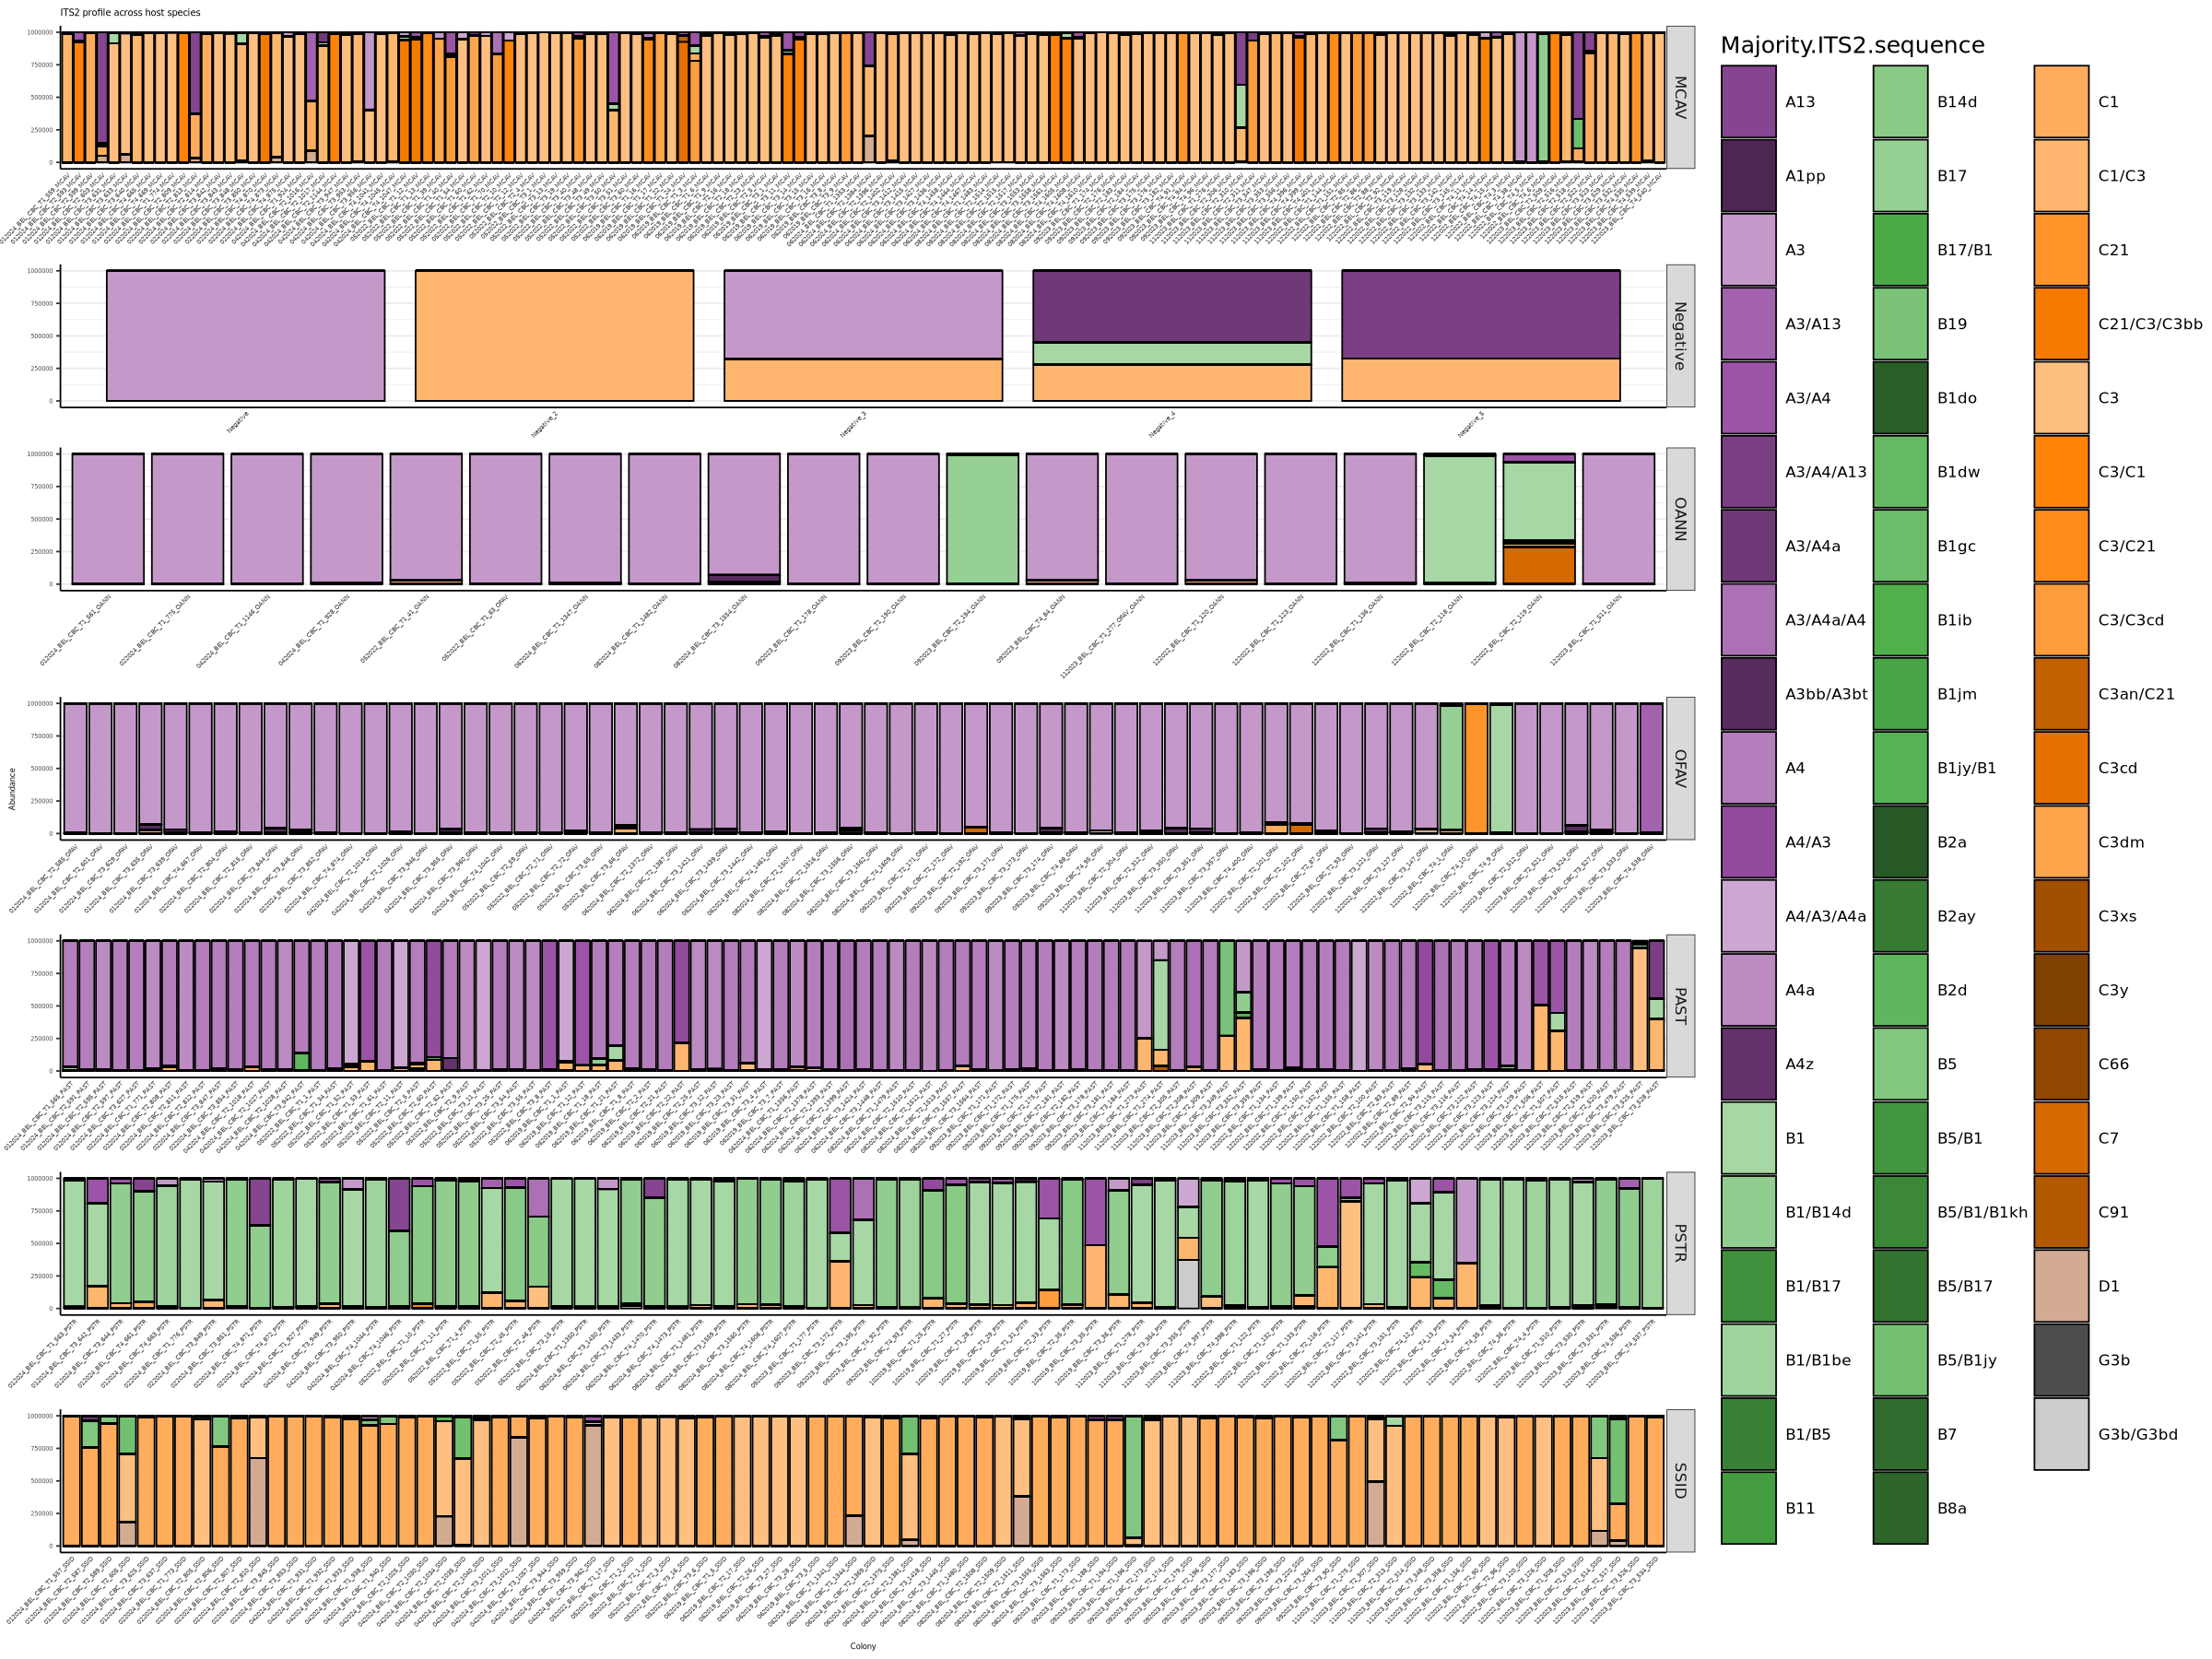

In [60]:
sam_profile <- plot_bar(ps_norm, fill = "Majority.ITS2.sequence") +
facet_wrap(Species ~., strip.position = "right",  ncol = 1, scales = "free_x") + # Set desired font size
  labs(title = "ITS2 profile across host species",
       x = "Colony",
       y = "Abundance",
       color = "Majority.ITS2.sequence") +
  scale_fill_manual(values = profile_colors, drop = TRUE) +
  scale_color_manual(values = profile_colors, drop = TRUE) +
  theme_bw() +
  theme(strip.text = element_text(size = 10), #facet text size
    legend.position = "right",
    legend.title = element_text(size = 15),
  legend.text = element_text(size = 10),
legend.key.width = unit(1.3, "cm"),     # make the legend keys wider
  legend.key.height = unit(1.7, "cm"),   # make them taller
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
    text = element_text(size = 5)
  )
guides(color = guide_legend(override.aes = list(size = 6))) 
sam_profile

<Guides[1] ggproto object>

colour : <GuideLegend>

Ignoring unknown labels:
• colour : "Majority.ITS2.sequence"
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's colour values.”


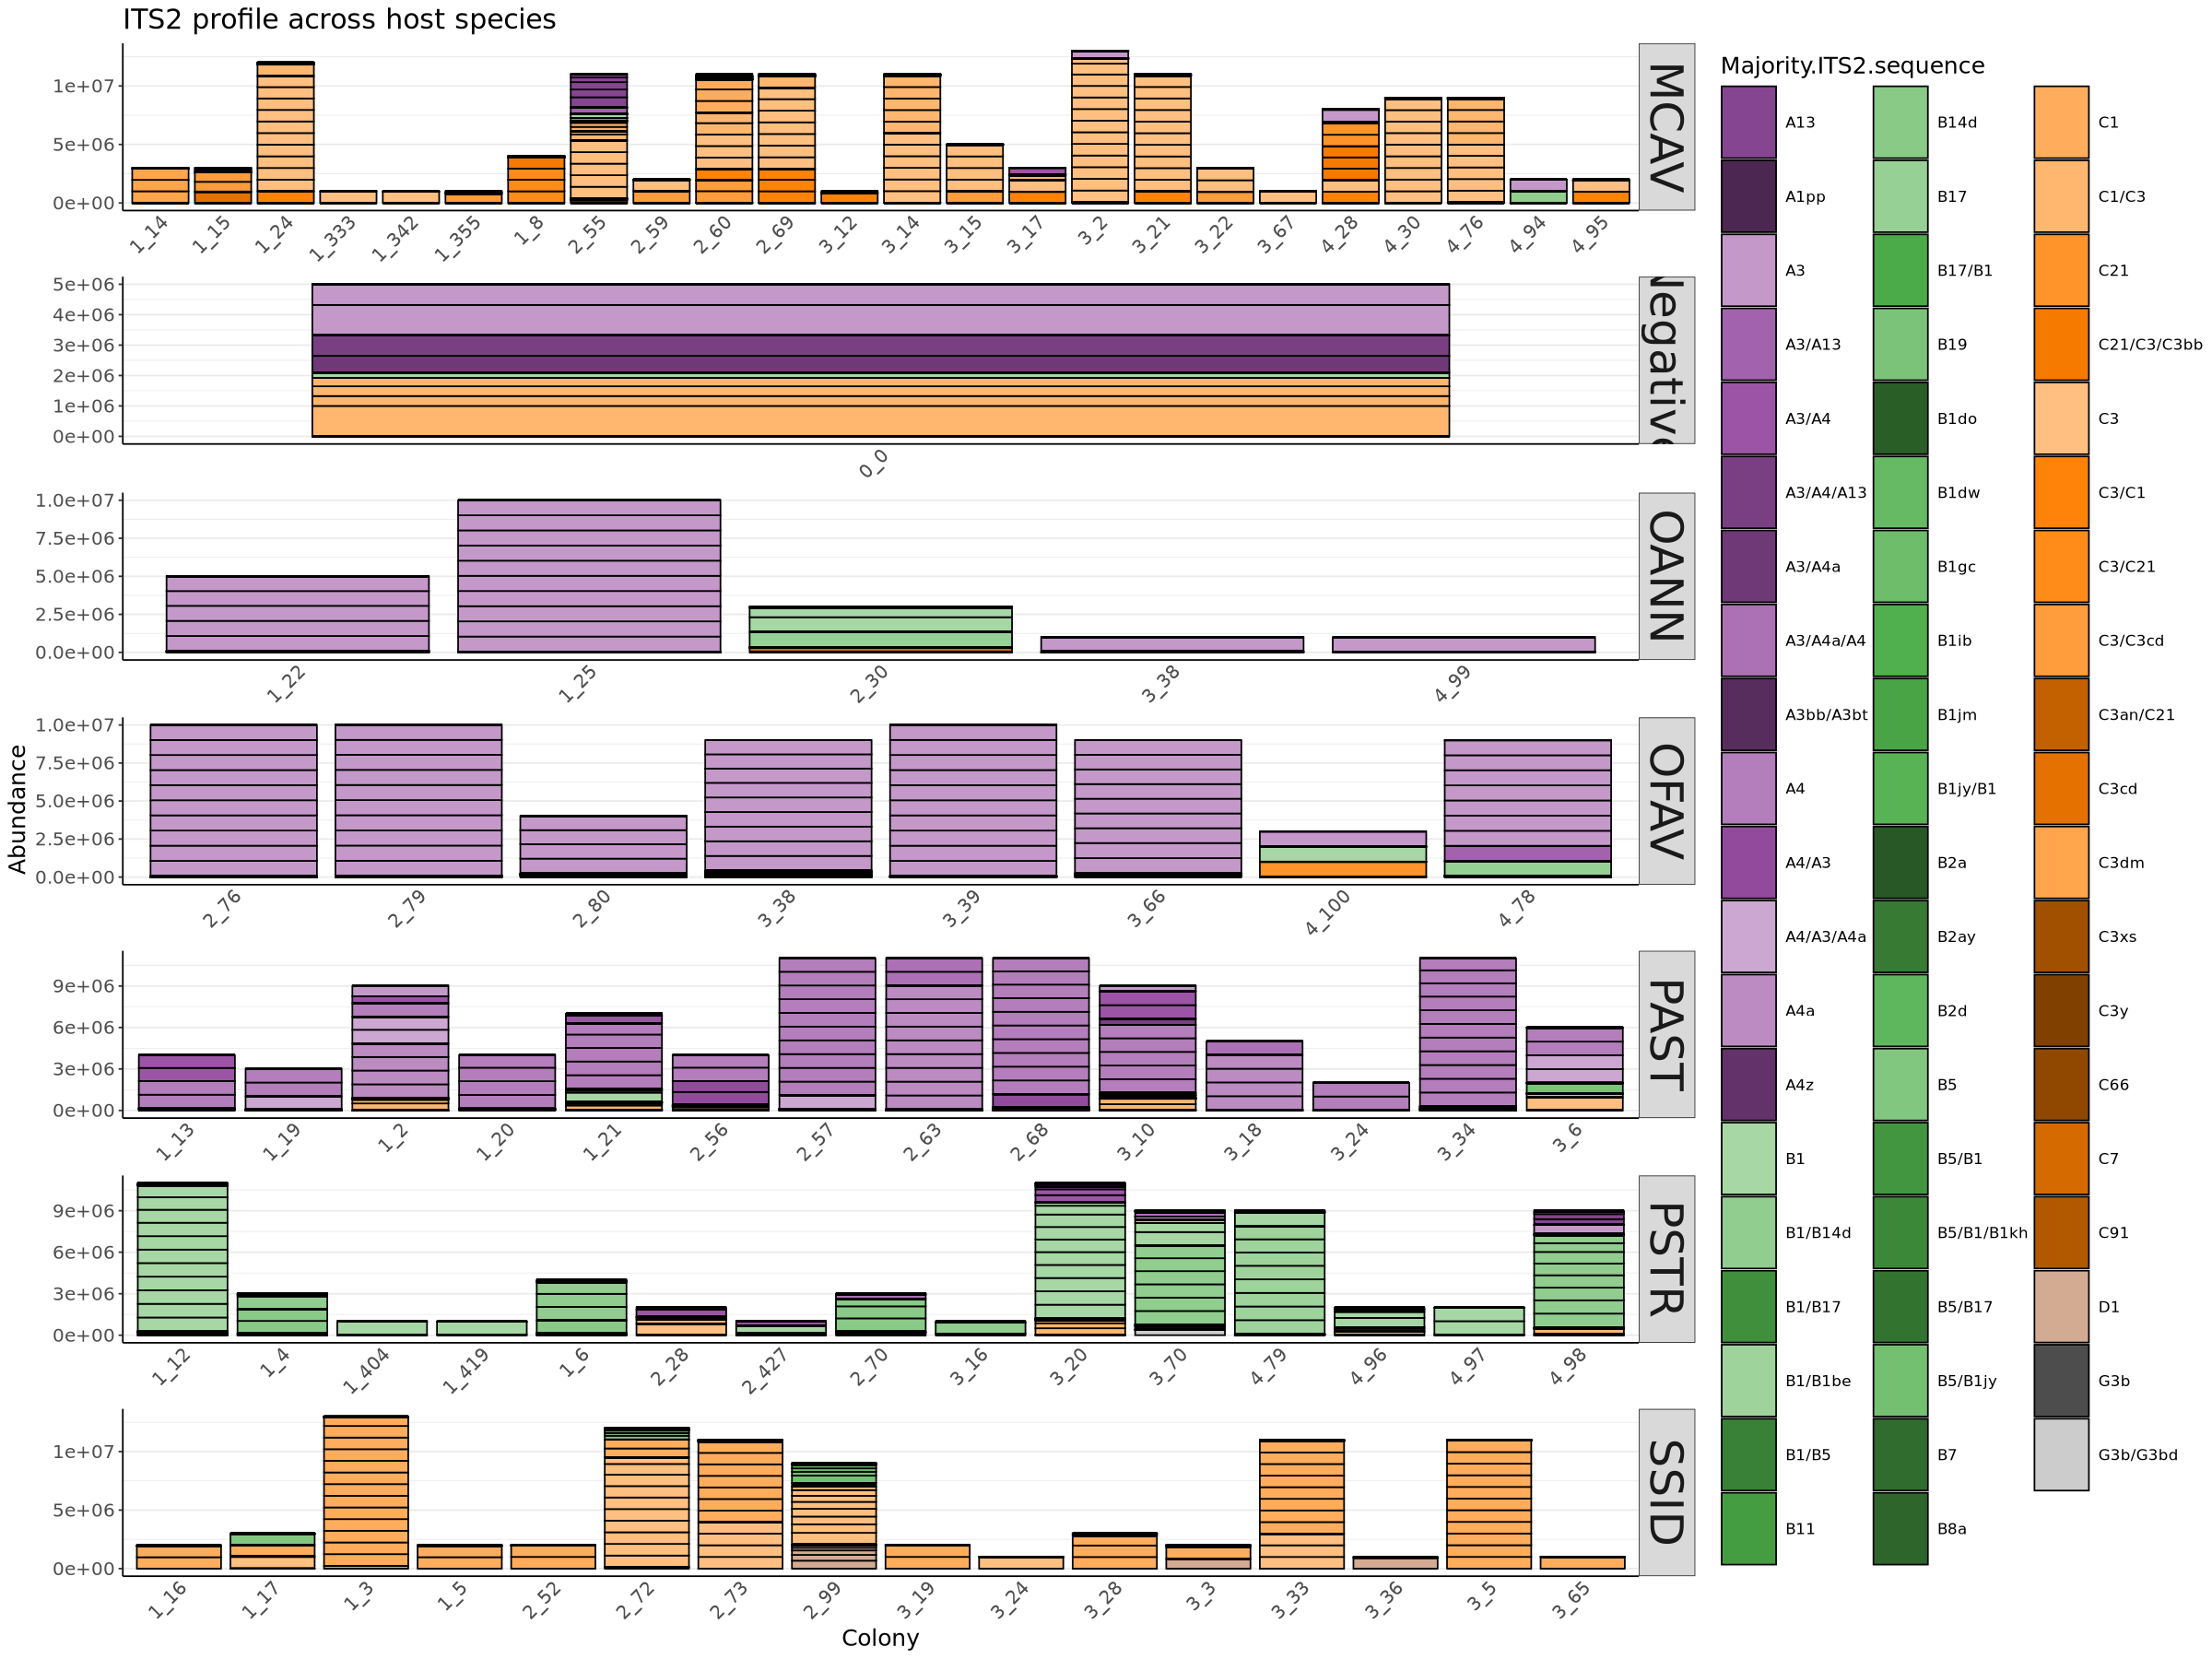

In [61]:
col_profile <- plot_bar(ps_norm, x = "colony", fill = "Majority.ITS2.sequence") +
facet_wrap(Species ~., strip.position = "right",  ncol = 1, scales = "free") + # Set desired font size
  labs(title = "ITS2 profile across host species",
       x = "Colony",
       y = "Abundance",
       color = "Majority.ITS2.sequence") +
  scale_fill_manual(values = profile_colors, drop = TRUE) +
  scale_color_manual(values = profile_colors, drop = TRUE) +
  theme_bw() +
  theme(strip.text = element_text(size = 30), #facet text size
    legend.position = "right",
    legend.title = element_text(size = 15),
  legend.text = element_text(size = 10),
legend.key.width = unit(1.3, "cm"),     # make the legend keys wider
  legend.key.height = unit(1.7, "cm"),   # make them taller
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
    text = element_text(size = 15)
  )
guides(color = guide_legend(override.aes = list(size = 6))) 
col_profile